# Final Course Project: Survival Prediction and Model Comparison

Oded Katz — 211862693 &nbsp;&nbsp;|&nbsp;&nbsp; Diana Morgan — 336472261


| Notebook section | Assignment item |
|---|---|
| 0. Setup and preprocessing | shared data preparation |
| 1. Recap of Project Assignment 1 | item 1 |
| 2. Recap of Project Assignment 2 | item 2 |
| 3. Research questions | item 3 |
| 4. Train-test split | item 4 |
| 5. Refitting the selected Cox model | item 5 |
| 6. One-year survival prediction (Cox) | item 6 |
| 7. Additional survival models (RSF, DeepSurv, Cox-Time) | item 7 |
| 8. Comparison of one-year prediction curves | item 8 |
| 9. Test-set model comparison | item 9 |
| 10. Additional analyses | item 10 |
| 11. Final discussion | item 11 |

---
## 0. Setup and preprocessing

We start from the dataset PA1 produced, where missing values were filled in with the median of each continuous covariate. No categorical covariate had missing values.

Two variables are built here because Section 2 onwards needs them:

* `n_comorbidities` — how many of the nine comorbidity indicators a patient has, grouped into `cat_comorbidities` with levels 0-1 (reference), 2-3 and 4+.
* `delta_BUN` — `BUN_discharge` minus `BUN_admission`, i.e. how far the blood urea nitrogen moved during the stay.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter

# ---- global configuration -------------------------------------------------
SEED = 42                      
np.random.seed(SEED)

DATA_PATH = os.path.join("..", "PA1", "imputed_data.csv")
FIG_DIR = "figures"
TAB_DIR = "tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

TIME_COL = "time_discharge_to_death_MONTHS"
EVENT_COL = "death"
HORIZON = 12.0                 
MAX_FOLLOWUP = 36.0           

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

In [2]:
df = pd.read_csv(DATA_PATH)

df = df.drop(columns=[c for c in ["survival_status"] if c in df.columns])

# ---- comorbidity burden (PA2) ---------------------------------------------
COMORBIDITY_COLS = ["diabetes", "hypertension", "COPD", "PVD",
                    "CKD", "IHD", "AF", "VHD", "PHTN"]

df["n_comorbidities"] = df[COMORBIDITY_COLS].sum(axis=1)
df["cat_comorbidities"] = pd.cut(
    df["n_comorbidities"],
    bins=[0, 1, 3, np.inf],
    include_lowest=True,
    labels=["0-1", "2-3", "4+"],
)

# ---- change in BUN during hospitalisation (PA2) ---------------------------
df["delta_BUN"] = df["BUN_discharge"] - df["BUN_admission"]

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(f"Any remaining missing values: {bool(df.isna().any().any())}")
df.head()

Rows: 3961   Columns: 30
Any remaining missing values: False


,gender_0male_1female,age_YEARS,diabetes,hypertension,COPD,PVD,CKD,IHD,AF,VHD,PHTN,BNP,BUN_admission,BUN_discharge,creatinine_admission,creatinine_discharge,GFR_admission,GFR_discharge,WBC,sodium,RDW,platelets,bilirubin,potassium,length_of_stay_DAYS,time_discharge_to_death_MONTHS,death,n_comorbidities,cat_comorbidities,delta_BUN
0,0,48.85803,0,0,0,0,0,0,0,0,0,1258.04,66.0,65.0,1.10,1.10,78.960885,80.768963,9.40,138.00,21.3,178.0,1.090,3.9,0.456785,5.000000,1,0,0-1,-1.0
1,0,49.67481,0,0,0,0,0,0,0,0,0,291.55,46.0,46.0,1.53,1.56,55.584022,54.435869,4.40,127.42,21.6,114.0,5.765,4.8,0.245513,0.700000,1,0,0-1,0.0
2,0,85.35892,0,0,0,0,0,0,0,0,0,1473.78,16.0,17.0,1.43,1.27,41.135539,48.993978,10.50,130.00,17.2,289.0,0.520,4.0,1.632458,8.033333,1,0,0-1,1.0
3,0,52.80388,0,0,0,0,0,0,0,0,0,940.32,28.3,30.0,1.43,1.13,55.718423,75.232868,8.50,135.00,13.3,188.0,0.550,6.1,5.921769,0.033333,1,0,0-1,1.7
4,0,67.30150,0,0,0,0,0,0,0,0,0,2625.98,59.0,28.0,2.65,2.32,26.914463,31.042884,13.17,136.40,14.7,274.0,0.500,5.3,17.214475,20.433333,0,0,0-1,-31.0


---
# 1. Brief recap of Project Assignment 1

PA1 constituted the exploratory analysis of the data: we characterized the covariates, addressed missing values, defined the survival outcome and censoring mechanism, and examined the Kaplan–Meier curves that informed the formulation of our research questions.

## 1.1 Dataset and survival outcome

The data is synthetic dataset 2. Every row is a patient admitted with acute decompensated heart failure who made it out of hospital alive. There are 27 columns: 25 covariates, the survival time, and the event indicator.

* **Event.** Death from any cause, `death = 1`.
* **Survival time.** `time_discharge_to_death_MONTHS`, from discharge to death or to the end of follow-up, in months.
* **Censoring.** Follow-up ends at 36 months. Patients with `death = 0` are right-censored, meaning that they are known to have survived until their last recorded follow-up time, while their status thereafter is unknown. Approximately two thirds of censored patients are censored at 36 months; the remainder leave follow-up earlier, with censoring times distributed relatively evenly across the observation period. We assume that censoring is independent of survival time conditional on the observed covariates.



## 1.2 Sample size, events and censoring

In [3]:
n_total = len(df)
n_events = int((df[EVENT_COL] == 1).sum())
n_censored = int((df[EVENT_COL] == 0).sum())

followup = df[TIME_COL]
is_censored = df[EVENT_COL] == 0

censored_at_end = int((is_censored & (followup >= MAX_FOLLOWUP)).sum())
censored_early = int((is_censored & (followup < MAX_FOLLOWUP)).sum())
early_times = followup[is_censored & (followup < MAX_FOLLOWUP)]

sample_summary = pd.DataFrame(
    {
        "n": [n_total, n_events, n_censored, censored_at_end, censored_early],
        "% of cohort": [
            100.0,
            100 * n_events / n_total,
            100 * n_censored / n_total,
            100 * censored_at_end / n_total,
            100 * censored_early / n_total,
        ],
    },
    index=[
        "Patients (sample size)",
        "Observed deaths (death = 1)",
        "Censored observations (death = 0)",
        "  of which administratively censored at 36 months",
        "  of which lost to follow-up before 36 months",
    ],
).round(2)

n_events_by_horizon = int(((df[EVENT_COL] == 1) & (followup <= HORIZON)).sum())
n_censored_pre_horizon = int((is_censored & (followup < HORIZON)).sum())

print("Follow-up time (months): "
      f"median = {followup.median():.2f}, "
      f"IQR = [{followup.quantile(.25):.2f}, {followup.quantile(.75):.2f}], "
      f"range = [{followup.min():.2f}, {followup.max():.2f}]")
print(f"Total person-months of follow-up: {followup.sum():,.0f}")
print(f"Censoring times of the {censored_early} lost to follow-up before {MAX_FOLLOWUP:.0f} months: "
      f"median = {early_times.median():.2f}, "
      f"IQR = [{early_times.quantile(.25):.2f}, {early_times.quantile(.75):.2f}]")
print(f"By the {HORIZON:.0f}-month horizon: {n_events_by_horizon} deaths, "
      f"{n_censored_pre_horizon} censored beforehand")
sample_summary

Follow-up time (months): median = 25.60, IQR = [8.83, 36.00], range = [0.00, 36.00]
Total person-months of follow-up: 88,266
Censoring times of the 809 lost to follow-up before 36 months: median = 16.47, IQR = [7.93, 25.37]
By the 12-month horizon: 947 deaths, 328 censored beforehand


,n,% of cohort
Patients (sample size),3961,100.00
Observed deaths (death = 1),1679,42.39
Censored observations (death = 0),2282,57.61
of which administratively censored at 36 months,1473,37.19
of which lost to follow-up before 36 months,809,20.42


In [4]:
sample_summary.to_csv(os.path.join(TAB_DIR, "table1a_sample_size.csv"))

**Table 1a**. There are 3,961 patients. 1,679 of them (42.4%) died during follow-up and 2,282 (57.6%) were censored. Of those censored, 1,473 reach the 36-month cutoff; the other 809 drop out earlier, at a median of 16.5 months. Median follow-up is 25.6 months, and the cohort contributes about 88,000 person-months in total.

## 1.3 Covariates

The 25 covariates group into five blocks: demographics, the nine comorbidity indicators, labs taken on admission, labs taken on discharge, and length of stay. Table 1 summarises them across the whole cohort, continuous variables as median [Q1, Q3] and binary ones as n (%).



In [5]:
LABELS = {
    "gender_0male_1female": "Female sex",
    "age_YEARS": "Age (years)",
    "diabetes": "Diabetes",
    "hypertension": "Hypertension",
    "COPD": "COPD",
    "PVD": "Peripheral vascular disease",
    "CKD": "Chronic kidney disease",
    "IHD": "Ischaemic heart disease",
    "AF": "Atrial fibrillation",
    "VHD": "Valvular heart disease",
    "PHTN": "Pulmonary hypertension",
    "BNP": "BNP, admission (pg/mL)",
    "BUN_admission": "BUN, admission (mg/dL)",
    "creatinine_admission": "Creatinine, admission (mg/dL)",
    "GFR_admission": "GFR, admission (mL/min/1.73m2)",
    "BUN_discharge": "BUN, discharge (mg/dL)",
    "creatinine_discharge": "Creatinine, discharge (mg/dL)",
    "GFR_discharge": "GFR, discharge (mL/min/1.73m2)",
    "WBC": "White blood cells (1000/uL)",
    "sodium": "Sodium (mEq/L)",
    "RDW": "Red cell distribution width (%)",
    "platelets": "Platelets (1000/uL)",
    "bilirubin": "Bilirubin (mg/dL)",
    "potassium": "Potassium (mEq/L)",
    "length_of_stay_DAYS": "Length of stay (days)",
}

BLOCKS = [
    ("Demographics", ["age_YEARS", "gender_0male_1female"]),
    ("Comorbidities (as recorded in PA1)", COMORBIDITY_COLS),
    ("Laboratory values on admission",
     ["BNP", "BUN_admission", "creatinine_admission", "GFR_admission"]),
    ("Laboratory values on discharge",
     ["BUN_discharge", "creatinine_discharge", "GFR_discharge"]),
    ("Other laboratory values",
     ["WBC", "sodium", "RDW", "platelets", "bilirubin", "potassium"]),
    ("Hospitalisation", ["length_of_stay_DAYS"]),
]

BINARY_COLS = ["gender_0male_1female"] + COMORBIDITY_COLS


def _continuous(series):
    return f"{series.median():.2f} [{series.quantile(.25):.2f}, {series.quantile(.75):.2f}]"


def _count(mask, n):
    k = int(mask.sum())
    return f"{k} ({100 * k / n:.1f}%)"


def build_covariate_table(data):
    n = len(data)
    rows = []
    for block, cols in BLOCKS:
        rows.append([f"[{block}]", "", ""])
        for col in cols:
            label = LABELS.get(col, col)
            if col in BINARY_COLS:
                rows.append([label, "n (%)", _count(data[col] == 1, n)])
            elif str(data[col].dtype) == "category":
                rows.append([label, "n (%)", ""])
                for level in data[col].cat.categories:
                    rows.append([f"    {level}", "", _count(data[col] == level, n)])
            else:
                rows.append([label, "median [Q1, Q3]", _continuous(data[col])])
    return pd.DataFrame(rows, columns=["Covariate", "Summary", f"All patients (n = {n})"])


table_one = build_covariate_table(df)
table_one.to_csv(os.path.join(TAB_DIR, "table1_covariates.csv"), index=False)
table_one.style.hide(axis="index")

Covariate,Summary,All patients (n = 3961)
[Demographics],,
Age (years),"median [Q1, Q3]","76.18 [66.85, 83.24]"
Female sex,n (%),1842 (46.5%)
[Comorbidities (as recorded in PA1)],,
Diabetes,n (%),2147 (54.2%)
Hypertension,n (%),3432 (86.6%)
COPD,n (%),405 (10.2%)
Peripheral vascular disease,n (%),367 (9.3%)
Chronic kidney disease,n (%),805 (20.3%)
Ischaemic heart disease,n (%),2484 (62.7%)


**Table 1**. Median age is 76 and 46.5% are women. The nine comorbidity columns are binary flags for conditions the patient already had before this admission, and most patients have several set at once: hypertension in 86.6%, ischaemic heart disease in 62.7%, diabetes in 54.2%, atrial fibrillation in 40.6%.

Median BUN goes from 25 mg/dL on admission to 28 at discharge. Stays are short, median 5.1 days. 


## 1.4 Overall Kaplan-Meier survival curve

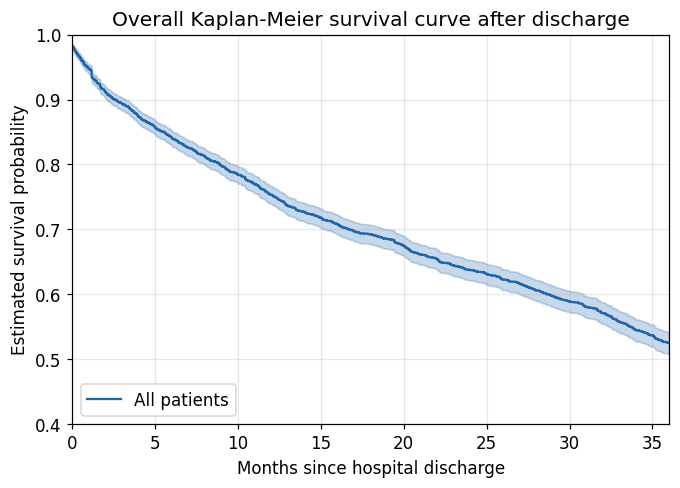

In [6]:
km = KaplanMeierFitter(label="All patients")
km.fit(durations=df[TIME_COL], event_observed=df[EVENT_COL])

fig, ax = plt.subplots(figsize=(7.0, 4.6))
km.plot_survival_function(ax=ax, ci_show=True, color="#2166ac")
ax.set_xlabel("Months since hospital discharge")
ax.set_ylabel("Estimated survival probability")
ax.set_title("Overall Kaplan-Meier survival curve after discharge")
ax.set_xlim(0, MAX_FOLLOWUP)
ax.set_ylim(0.4, 1.0)
ax.legend(loc="lower left")
fig.savefig(os.path.join(FIG_DIR, "fig1_km_overall.png"))
plt.show()

Figure 1. Survival falls steadily across the three years, from 1 at discharge down to about 0.53 at 36 months. The drop is fastest in the first few months and then settles into a roughly straight line. Around three quarters of the cohort are still alive at one year.

## 1.5 Stratified Kaplan-Meier curves

PA1 stratified the survival curves by sex and by diabetes. Both are reproduced below, each panel with a log-rank test for equality of the two curves.

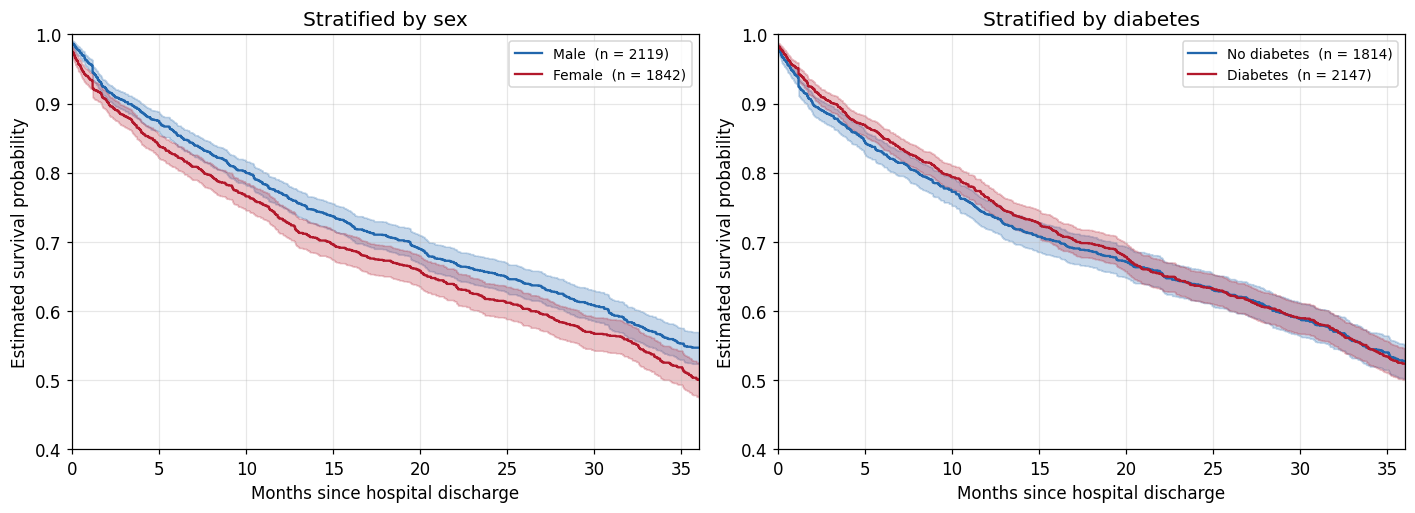

Sex        S(12)|Male = 0.770  S(12)|Female = 0.733
Diabetes   S(12)|No diabetes = 0.740  S(12)|Diabetes = 0.764


In [7]:
PALETTE = ["#2166ac", "#b2182b", "#1b7837"]


def plot_km_strata(ax, data, groups, title, ylim=(0.4, 1.0)):
    # groups: list of (label, boolean mask)
    surv_at_horizon = {}
    for (label, mask), color in zip(groups, PALETTE):
        sub = data[mask]
        f = KaplanMeierFitter(label=f"{label}  (n = {int(mask.sum())})")
        f.fit(durations=sub[TIME_COL], event_observed=sub[EVENT_COL])
        f.plot_survival_function(ax=ax, ci_show=True, color=color)
        surv_at_horizon[label] = float(f.survival_function_at_times([HORIZON]).iloc[0])

    ax.set_xlabel("Months since hospital discharge")
    ax.set_ylabel("Estimated survival probability")
    ax.set_title(title)
    ax.set_xlim(0, MAX_FOLLOWUP)
    ax.set_ylim(*ylim)
    ax.legend(loc="upper right", fontsize=9)
    return surv_at_horizon


fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

s_sex = plot_km_strata(
    axes[0], df,
    [("Male", df["gender_0male_1female"] == 0),
     ("Female", df["gender_0male_1female"] == 1)],
    "Stratified by sex",
)

s_dm = plot_km_strata(
    axes[1], df,
    [("No diabetes", df["diabetes"] == 0),
     ("Diabetes", df["diabetes"] == 1)],
    "Stratified by diabetes",
)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig2_km_stratified.png"))
plt.show()

for name, s in [("Sex", s_sex), ("Diabetes", s_dm)]:
    print(f"{name:10s} " + "  ".join(f"S(12)|{k} = {v:.3f}" for k, v in s.items()))

Figure 2. PA1's two stratifications.

* **Sex.** The male curve sits a little above the female one for the whole three years, 0.77 against 0.73 at one year. The confidence bands overlap over almost all of the follow-up, so the two curves are not clearly separated. 
* **Diabetes.** The two curves lie on top of each other and the bands overlap everywhere.

Neither split separates the cohort usefully. 

Neither of PA1's splits separates the cohort. Two that do are age and the BUN measured at discharge, both split at their medians.

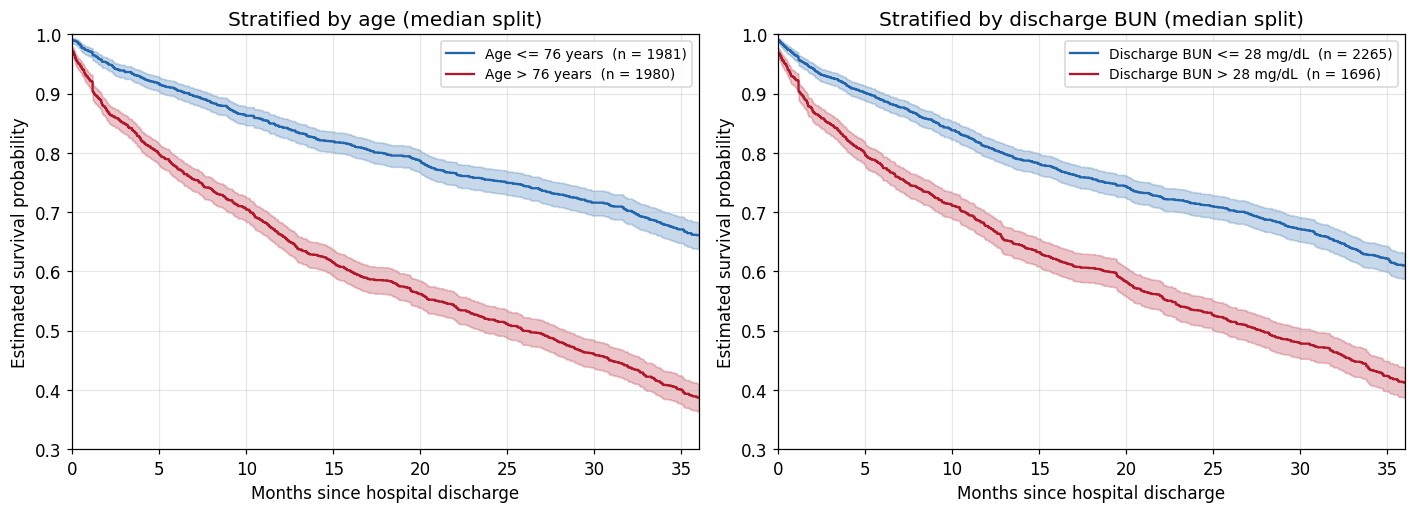

Age            S(12)|Age <= 76 years = 0.844  S(12)|Age > 76 years = 0.661
Discharge BUN  S(12)|Discharge BUN <= 28 mg/dL = 0.810  S(12)|Discharge BUN > 28 mg/dL = 0.676


In [8]:
age_median = df["age_YEARS"].median()
bun_median = df["BUN_discharge"].median()

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

s_age = plot_km_strata(
    axes[0], df,
    [(f"Age <= {age_median:.0f} years", df["age_YEARS"] <= age_median),
     (f"Age > {age_median:.0f} years", df["age_YEARS"] > age_median)],
    "Stratified by age (median split)",
    ylim=(0.3, 1.0),
)

s_bun = plot_km_strata(
    axes[1], df,
    [(f"Discharge BUN <= {bun_median:.0f} mg/dL", df["BUN_discharge"] <= bun_median),
     (f"Discharge BUN > {bun_median:.0f} mg/dL", df["BUN_discharge"] > bun_median)],
    "Stratified by discharge BUN (median split)",
    ylim=(0.3, 1.0),
)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig3_km_age_bun.png"))
plt.show()

for name, s in [("Age", s_age), ("Discharge BUN", s_bun)]:
    print(f"{name:14s} " + "  ".join(f"S(12)|{k} = {v:.3f}" for k, v in s.items()))

Figure 3. Both splits open a gap early and hold it for the whole three years, and in both cases the confidence bands stay clear of each other from the first month to the last.

* **Age.** Above the median of 76 years, one-year survival is 0.66 against 0.84 below it.
* **Discharge BUN.** Above the median of 28 mg/dL, one-year survival is 0.68 against 0.81.

Compare Figure 2, where sex moves one-year survival by 0.04 with overlapping bands and diabetes moves it by nothing at all. These two move it by 0.18 and 0.13, with no overlap anywhere. 

## 1.6 Research questions motivating the analysis

PA1 finished with a preliminary Cox model on all 25 covariates. Age, RDW, sodium, BUN on both admission and discharge, BNP, length of stay, COPD, bilirubin and potassium came out significant; the demographics and most of the comorbidity indicators did not. Together with the curves above, that gave us three questions:

> RQ1. Does the change in BUN between admission and discharge tell us anything about post-discharge survival that the discharge BUN level does not already?
>
> RQ2. Are there interactions between covariates that matter for survival?
>
> RQ3. How well can we predict a patient's survival at the moment they are discharged, using only what is known then?



---
# 2. Brief recap of Project Assignment 2

PA2 moved from description to modelling. It replaced the nine comorbidity flags with the burden variable, fitted a Cox proportional hazards model, tested whether the change in BUN during the stay adds anything on top of the discharge value, checked the proportional hazards assumption, and compared the Cox model against a log-normal AFT model for one-year prediction. 

## 2.1 The selected model

The model PA2 settled on has fifteen terms: sex, age, comorbidity burden (0-1 as the reference level, 2-3, 4+), length of stay, BUN at discharge, creatinine at discharge, GFR at discharge, BNP, white blood cells, sodium, RDW, platelets, bilirubin, potassium, and `delta_BUN`.

In [9]:
from lifelines import CoxPHFitter

PA2_FORMULA = ("gender_0male_1female + age_YEARS + C(cat_comorbidities) + "
               "length_of_stay_DAYS + BUN_discharge + creatinine_discharge + GFR_discharge + "
               "BNP + WBC + sodium + RDW + platelets + bilirubin + potassium + delta_BUN")

cox_pa2 = CoxPHFitter().fit(df, duration_col=TIME_COL, event_col=EVENT_COL, formula=PA2_FORMULA)
print(f"Concordance: {cox_pa2.concordance_index_:.4f}")

pa2_hr = (cox_pa2.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
          .round(4).sort_values("p"))
pa2_hr.to_csv(os.path.join(TAB_DIR, "table2_pa2_cox.csv"))
pa2_hr

Concordance: 0.6943


,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age_YEARS,1.0438,1.0382,1.0495,0.0000
BUN_discharge,1.0213,1.0176,1.0249,0.0000
sodium,0.9728,0.9627,0.9831,0.0000
BNP,1.0002,1.0001,1.0002,0.0000
delta_BUN,0.9903,0.9867,0.9938,0.0000
RDW,1.1204,1.0903,1.1514,0.0000
length_of_stay_DAYS,1.0094,1.0037,1.0151,0.0011
bilirubin,1.1208,1.0068,1.2477,0.0372
potassium,0.9141,0.8397,0.9951,0.0382


**Table 2**. Nine terms are significant at the 5% level : **Age, BUN at discharge, sodium, BNP, delta BUN, RDW, length of stay, bilirubin, and potassium**. Age is 1.044 per year, so a ten-year gap multiplies the hazard by about 1.5. Discharge BUN is 1.021 per mg/dL, RDW 1.120 per unit, bilirubin 1.121, length of stay 1.009 per day. Sodium at 0.973 and potassium at 0.914 run the other way. BNP is 1.0002 per pg/mL, which is not negligible as the variable runs into the thousands.

Neither comorbidity burden level is significant: 0.89 for 2-3 against the 0-1 reference, 0.99 for 4+. Sex, white blood cells, discharge creatinine, discharge GFR and platelets are insignifficant as well. 


## 2.2 Does the change in BUN add anything?

Yes, and thus `delta_BUN` is included in the model above. PA2 compared the fit with and without it using a likelihood-ratio test and got 27.63 on 1 degree of freedom, p = 1.5e-07, so the change in BUN over the stay carries information the discharge value alone does not. 

## 2.3 Proportional hazards diagnostics

The Cox model assumes each covariate's hazard ratio is constant over follow-up. PA2 checked this with the Schoenfeld residual test using a rank transform of time. The cell below repeats that test on the selected model.

In [10]:
from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(cox_pa2, df, time_transform="rank")
ph_summary = ph_test.summary[["test_statistic", "p"]].round(4).sort_values("p")
ph_summary.to_csv(os.path.join(TAB_DIR, "table4_ph_test.csv"))

print(f"Covariates with p < 0.05: {int((ph_summary['p'] < 0.05).sum())} of {len(ph_summary)}")
ph_summary

Covariates with p < 0.05: 2 of 16


,test_statistic,p
BUN_discharge,4.3917,0.0361
length_of_stay_DAYS,3.9114,0.0480
creatinine_discharge,2.7398,0.0979
C(cat_comorbidities)[T.4+],2.7004,0.1003
bilirubin,2.4538,0.1172
sodium,1.6433,0.1999
C(cat_comorbidities)[T.2-3],1.3876,0.2388
gender_0male_1female,1.2686,0.2600
age_YEARS,1.0640,0.3023
GFR_discharge,0.8278,0.3629


**Table 4**. Two terms come out under 0.05: discharge BUN at 0.036 and length of stay at 0.048. Both are only just under. The other fourteen are safe.

Overall, the formal tests suggest mild possible violations, but the graphical evidence (showed in PA2) is not very clear or severe.

## 2.4 Cox against the log-normal AFT model

PA2 also fitted a log-normal accelerated failure time model on the same covariates. An AFT model works on survival time rather than on the hazard, so the signs read the other way round: a positive coefficient means longer survival.

The two models agreed on direction throughout. Age, discharge BUN, RDW, bilirubin and length of stay all came out negative in the AFT fit, matching hazard ratios above 1 in the Cox model. Sodium came out positive, matching its hazard ratio below 1. `delta_BUN` came out positive too, matching the 0.990 discussed above.


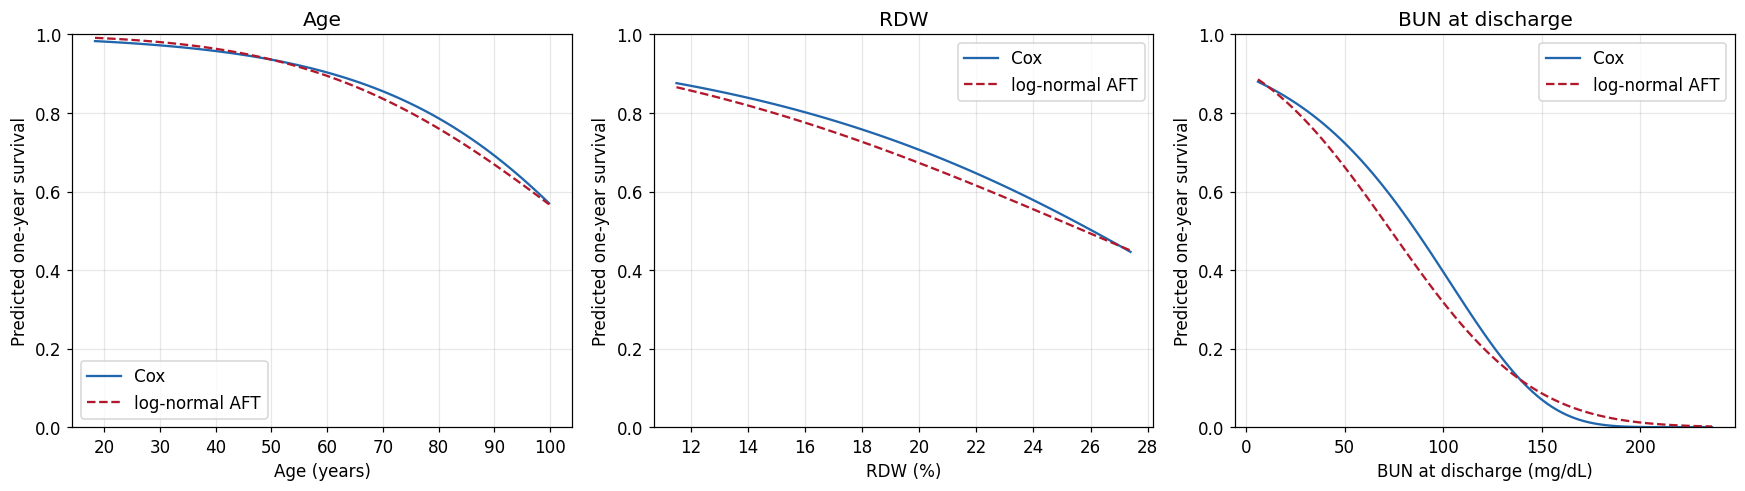

                     representative value
gender_0male_1female                  0.0
age_YEARS                        76.18272
cat_comorbidities                     2-3
length_of_stay_DAYS              5.128474
BUN_discharge                        28.0
creatinine_discharge                 1.23
GFR_discharge                   50.433085
BNP                                 778.1
WBC                                  8.92
sodium                              138.0
RDW                                  15.3
platelets                           225.0
bilirubin                             0.6
potassium                             4.3
delta_BUN                             3.0


In [11]:
from lifelines import LogNormalAFTFitter

# the log-normal AFT model needs strictly positive times
aft_df = df.copy()
aft_df.loc[aft_df[TIME_COL] <= 0, TIME_COL] = 0.01
aft_pa2 = LogNormalAFTFitter().fit(aft_df, duration_col=TIME_COL, event_col=EVENT_COL,
                                   formula=PA2_FORMULA)

MODEL_VARS = ["gender_0male_1female", "age_YEARS", "cat_comorbidities", "length_of_stay_DAYS",
              "BUN_discharge", "creatinine_discharge", "GFR_discharge", "BNP", "WBC", "sodium",
              "RDW", "platelets", "bilirubin", "potassium", "delta_BUN"]


def representative_row(data, columns):
    # median for continuous covariates, most common level for categorical ones
    row = {}
    for col in columns:
        if pd.api.types.is_numeric_dtype(data[col]):
            row[col] = [data[col].median()]
        else:
            row[col] = [data[col].mode().iloc[0]]
    return pd.DataFrame(row)


def one_year_curve(model, covariate, grid, base):
    rows = pd.concat([base.assign(**{covariate: v}) for v in grid], ignore_index=True)
    return model.predict_survival_function(rows, times=[HORIZON]).iloc[0].values


base_row = representative_row(df, MODEL_VARS)

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
for ax, cov, label in zip(axes,
                          ["age_YEARS", "RDW", "BUN_discharge"],
                          ["Age (years)", "RDW (%)", "BUN at discharge (mg/dL)"]):
    grid = np.linspace(df[cov].min(), df[cov].max(), 120)
    ax.plot(grid, one_year_curve(cox_pa2, cov, grid, base_row), color="#2166ac", label="Cox")
    ax.plot(grid, one_year_curve(aft_pa2, cov, grid, base_row), color="#b2182b",
            linestyle="--", label="log-normal AFT")
    ax.set_xlabel(label)
    ax.set_ylabel("Predicted one-year survival")
    ax.set_title(label.split(" (")[0])
    ax.set_ylim(0, 1)
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig4_cox_vs_aft.png"))
plt.show()

print(base_row.T.rename(columns={0: "representative value"}).to_string())

Figure 4. Each panel sweeps one covariate across its observed range and holds everything else at the representative values printed under the figure: the median for continuous covariates, the most common level for comorbidity burden, which is 2-3.

For age the two curves are almost indistinguishable. For RDW they separate a little, the AFT model predicting slightly lower across the middle of the range, and they meet again at the top. Discharge BUN shows the widest gap: the AFT curve falls faster between roughly 20 and 120 mg/dL, then flattens and crosses above the Cox curve in the tail. Worth noting that the BUN axis runs to 236 mg/dL because that is the observed maximum, but three quarters of patients sit below 39, so nearly all the data lives in the left fifth of that panel.


---
# 3. Research questions



## 3.1 The questions from Project Assignment 1

Project Assignment 1 closed with three questions:

> RQ1 (PA1). Does the difference between BUN on admission and BUN on discharge have a significant effect on the survival outcome?
>
> RQ2 (PA1). Are there covariate interactions with a significant effect on the survival outcome?
>
> RQ3 (PA1). How accurately can a patient's survival outcome be predicted at hospital discharge?

The first question has been answered. PA2 added `delta_BUN` to the Cox model and the likelihood-ratio test was significant, 27.63 on one degree of freedom with p = 1.5e-07, so the change in BUN over the admission does carry information beyond the discharge value alone.

The second question was never addressed. Neither assignment fitted an interaction term. As originally phrased the question also does not say which interactions to look for, and with fifteen covariates there are 105 pairwise terms, so testing all of them would produce significant results by chance alone. We keep the question, but narrow it to two interactions chosen in advance. Section 3.2 sets them out.

The third question was not addressed either. PA1 and PA2 both fitted models to the full dataset and reported in-sample summaries. Neither held any data out, so neither produced an honest estimate of how well survival can actually be predicted.

## 3.2 Final research questions

The three questions below guide the rest of the project. Each descends from one of the PA1 questions, and each is answered by analyses the assignment already requires.

> **RQ1.** How accurately can one-year survival be predicted from the information available at discharge, and do the more flexible models predict better than the Cox model?

This is PA1's third question made specific. Section 4 splits the data into training and test sets. Sections 5 and 7 fit the Cox model, a random survival forest, DeepSurv and Cox-Time on the training set. Section 9 compares them. 

> **RQ2.** Where the more flexible models differ from the Cox model, which of the Cox model's assumptions is responsible?

The Cox model assumes three separate things: that each covariate acts linearly on the log hazard, that covariate effects add together without interacting, and that hazard ratios stay constant over follow-up. The three additional models give up different combinations of these. DeepSurv replaces the linear predictor with a neural network, so it allows non-linear effects and interactions, but it keeps hazards proportional. Cox-Time lets the risk score depend on time as well, so hazard ratios need not be constant. The random survival forest assumes none of the three, since it splits the data recursively and estimates a separate cumulative hazard in each terminal node.


Section 2.3 gives one concrete reason to ask. The proportional hazards assumption came out borderline for discharge BUN, p = 0.036, and for length of stay, p = 0.048. The prediction curves in Section 8 will show whether the flexible models see age, RDW and discharge BUN the same way the Cox model does, and the test-set results in Section 9 will show whether any of the differences improve prediction.


> **RQ3.** Do the two interactions specified below improve on the additive Cox model?

This is PA1's second question, narrowed to something that can be answered. Rather than searching over all 105 pairwise terms, we fix two in advance and give the reason for each.

The first is between `delta_BUN` and discharge BUN. The change and the level are closely tied, since `delta_BUN` is discharge minus admission, and the same change plausibly means different things depending on the level the patient reached. A rise of 10 mg/dL in someone leaving at 25 is not the same situation as the same rise in someone leaving at 60, yet the additive model assigns both the same effect. An interaction lets the effect of the change depend on the discharge level, which is the natural way to ask whether the two carry information jointly rather than separately.

The second is between age and discharge BUN, the two strongest predictors in Table 2. Whether reduced kidney clearance carries the same risk at 60 as it does at 85 is a question with a clear reading either way.

Each interaction is a single term added to the Section 5 model and tested by a likelihood-ratio test on the training data, in Section 10. Two tests chosen in advance keep multiplicity to a footnote rather than a problem.

---
# 4. Train-test split

We use an 80/20 split into a training set and a test set, with the random seed fixed at 42. The seed is set in Section 0 and is the same one used for every random step in the project.

The split is stratified by the event indicator, so the training and test sets carry close to the same proportion of deaths. 


In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df[EVENT_COL]
)

split_summary = pd.DataFrame(
    {
        "n": [len(train_df), len(test_df)],
        "events": [int(train_df[EVENT_COL].sum()), int(test_df[EVENT_COL].sum())],
        "event rate": [train_df[EVENT_COL].mean(), test_df[EVENT_COL].mean()],
        "deaths by 12 months": [
            int(((train_df[EVENT_COL] == 1) & (train_df[TIME_COL] <= HORIZON)).sum()),
            int(((test_df[EVENT_COL] == 1) & (test_df[TIME_COL] <= HORIZON)).sum()),
        ],
    },
    index=["Training", "Test"],
).round(4)

print(f"Random seed: {SEED}")
split_summary

Random seed: 42


,n,events,event rate,deaths by 12 months
Training,3168,1343,0.4239,748
Test,793,336,0.4237,199


**Table 4**. The split gives 3,168 patients for training and 793 for testing, with event rates of 42.4% in both, as the stratification ensures. 

---
# 5. Refitting the selected Cox model

## 5.1 Estimates on the training data

The model is the one PA2 selected, refitted on the 3,168 training patients only. The table below puts the training estimates next to the full-data estimates from Section 2 so the two can be read together.

In [13]:
cox_train = CoxPHFitter().fit(train_df, duration_col=TIME_COL, event_col=EVENT_COL,
                              formula=PA2_FORMULA)

train_vs_full = pd.DataFrame({
    "HR (train)": cox_train.hazard_ratios_,
    "lower 95%": cox_train.summary["exp(coef) lower 95%"],
    "upper 95%": cox_train.summary["exp(coef) upper 95%"],
    "p (train)": cox_train.summary["p"],
    "HR (full)": cox_pa2.hazard_ratios_,
    "p (full)": cox_pa2.summary["p"],
})
train_vs_full["HR change %"] = 100 * (train_vs_full["HR (train)"] / train_vs_full["HR (full)"] - 1)
train_vs_full = train_vs_full.sort_values("p (full)").round(4)
train_vs_full.to_csv(os.path.join(TAB_DIR, "table5_cox_train_vs_full.csv"))

inside = ((train_vs_full["HR (full)"] >= train_vs_full["lower 95%"]) &
          (train_vs_full["HR (full)"] <= train_vs_full["upper 95%"])).all()
print(f"Training set: {len(train_df)} patients, {int(train_df[EVENT_COL].sum())} events")
print(f"Concordance: {cox_train.concordance_index_:.4f} on training, "
      f"{cox_pa2.concordance_index_:.4f} for the full-data fit")
print(f"Largest change in any hazard ratio: {train_vs_full['HR change %'].abs().max():.1f}%")
print(f"Every full-data hazard ratio inside the training 95% CI: {inside}")
train_vs_full

Training set: 3168 patients, 1343 events
Concordance: 0.6995 on training, 0.6943 for the full-data fit
Largest change in any hazard ratio: 2.2%
Every full-data hazard ratio inside the training 95% CI: True


,HR (train),lower 95%,upper 95%,p (train),HR (full),p (full),HR change %
covariate,,,,,,,
age_YEARS,1.0447,1.0384,1.0511,0.0000,1.0438,0.0000,0.0847
BUN_discharge,1.0238,1.0197,1.0279,0.0000,1.0213,0.0000,0.2476
RDW,1.1295,1.0963,1.1638,0.0000,1.1204,0.0000,0.8157
delta_BUN,0.9900,0.9861,0.9940,0.0000,0.9903,0.0000,-0.0225
BNP,1.0002,1.0001,1.0002,0.0000,1.0002,0.0000,0.0001
sodium,0.9726,0.9611,0.9843,0.0000,0.9728,0.0000,-0.0236
length_of_stay_DAYS,1.0083,1.0020,1.0146,0.0100,1.0094,0.0011,-0.1081
bilirubin,1.0988,0.9738,1.2400,0.1263,1.1208,0.0372,-1.9582
potassium,0.9196,0.8376,1.0096,0.0784,0.9141,0.0382,0.5936


**Table 5**. The estimates are stable. No hazard ratio moves by more than 2.2%, and every full-data estimate falls inside the corresponding training confidence interval, which is what we would hope for when the training set is 80% of the same data.

Two covariates lose significance: bilirubin goes from p = 0.037 to 0.126, and potassium from 0.038 to 0.078. Neither effect actually changed. Bilirubin moves from 1.121 to 1.099 and potassium from 0.914 to 0.920; what changed is the width of the intervals, since a fifth of the data has been set aside. Both were marginal in the full fit, so both were always liable to cross the 5% line under a smaller sample.

The seven covariates carrying the model are untouched. Age, discharge BUN, sodium, BNP, delta_BUN, RDW and length of stay all remain significant, with hazard ratios essentially unchanged. Concordance is 0.699 on the training data against 0.694 for the full-data fit.

So the conclusions do not change meaningfully. The model says the same thing fitted on 3,168 patients as it did on 3,961, with slightly less certainty about the two weakest terms.

## 5.2 Proportional hazards on the training data

The same Schoenfeld residual test as in Section 2.3, now on the refitted model, with the full-data p-values alongside for comparison.

In [14]:
ph_train = proportional_hazard_test(cox_train, train_df, time_transform="rank").summary
ph_full = proportional_hazard_test(cox_pa2, df, time_transform="rank").summary

ph_compare = pd.DataFrame({
    "statistic (train)": ph_train["test_statistic"],
    "p (train)": ph_train["p"],
    "statistic (full)": ph_full["test_statistic"],
    "p (full)": ph_full["p"],
}).sort_values("p (train)").round(4)
ph_compare.to_csv(os.path.join(TAB_DIR, "table6_ph_train_vs_full.csv"))

flagged_train = list(ph_compare.index[ph_compare["p (train)"] < 0.05])
flagged_full = list(ph_compare.index[ph_compare["p (full)"] < 0.05])
print(f"Flagged on training data ({len(flagged_train)} of {len(ph_compare)}): {flagged_train}")
print(f"Flagged on full data     ({len(flagged_full)} of {len(ph_compare)}): {flagged_full}")
print(f"Flagged in both: {sorted(set(flagged_train) & set(flagged_full)) or 'none'}")
ph_compare

Flagged on training data (3 of 16): ['C(cat_comorbidities)[T.4+]', 'C(cat_comorbidities)[T.2-3]', 'bilirubin']
Flagged on full data     (2 of 16): ['BUN_discharge', 'length_of_stay_DAYS']
Flagged in both: none


,statistic (train),p (train),statistic (full),p (full)
C(cat_comorbidities)[T.4+],5.3661,0.0205,2.7004,0.1003
C(cat_comorbidities)[T.2-3],5.0600,0.0245,1.3876,0.2388
bilirubin,4.4517,0.0349,2.4538,0.1172
creatinine_discharge,3.1585,0.0755,2.7398,0.0979
BUN_discharge,2.4654,0.1164,4.3917,0.0361
length_of_stay_DAYS,2.2173,0.1365,3.9114,0.0480
delta_BUN,2.1407,0.1434,0.6245,0.4294
gender_0male_1female,1.7093,0.1911,1.2686,0.2600
GFR_discharge,1.0308,0.3100,0.8278,0.3629
potassium,0.9632,0.3264,0.6007,0.4383


**Table 6**. The formal test gives a different answer on the training data.

On the full data the two covariates under 0.05 were discharge BUN (0.036) and length of stay (0.048). On the training data neither is flagged: discharge BUN rises to 0.116 and length of stay to 0.137. Three others fall below the line instead: both comorbidity burden levels, 4+ at 0.021 and 2-3 at 0.025, and bilirubin at 0.035. On the full data those three sat at 0.100, 0.239 and 0.117.

The two sets of flags have no covariate in common. The training set is not independent data: those 3,168 patients make up most of the 3,961 used for the full fit. A hazard ratio that genuinely changed over follow-up in the full cohort would therefore still be changing in the training subset, since the same patients produced both results. Instead discharge BUN moves from 0.036 to 0.116, and three covariates that were far from significant on the full data fall below 0.05.

The smallest p-value anywhere in either fit is 0.021, so even the flagged covariates sit just past the threshold rather than well beyond it.

This matches the conclusion reached in Section 2.3. The proportional hazards assumption is an adequate approximation for this model, and the hazard ratios in Table 5 describe an average effect over the three years of follow-up.

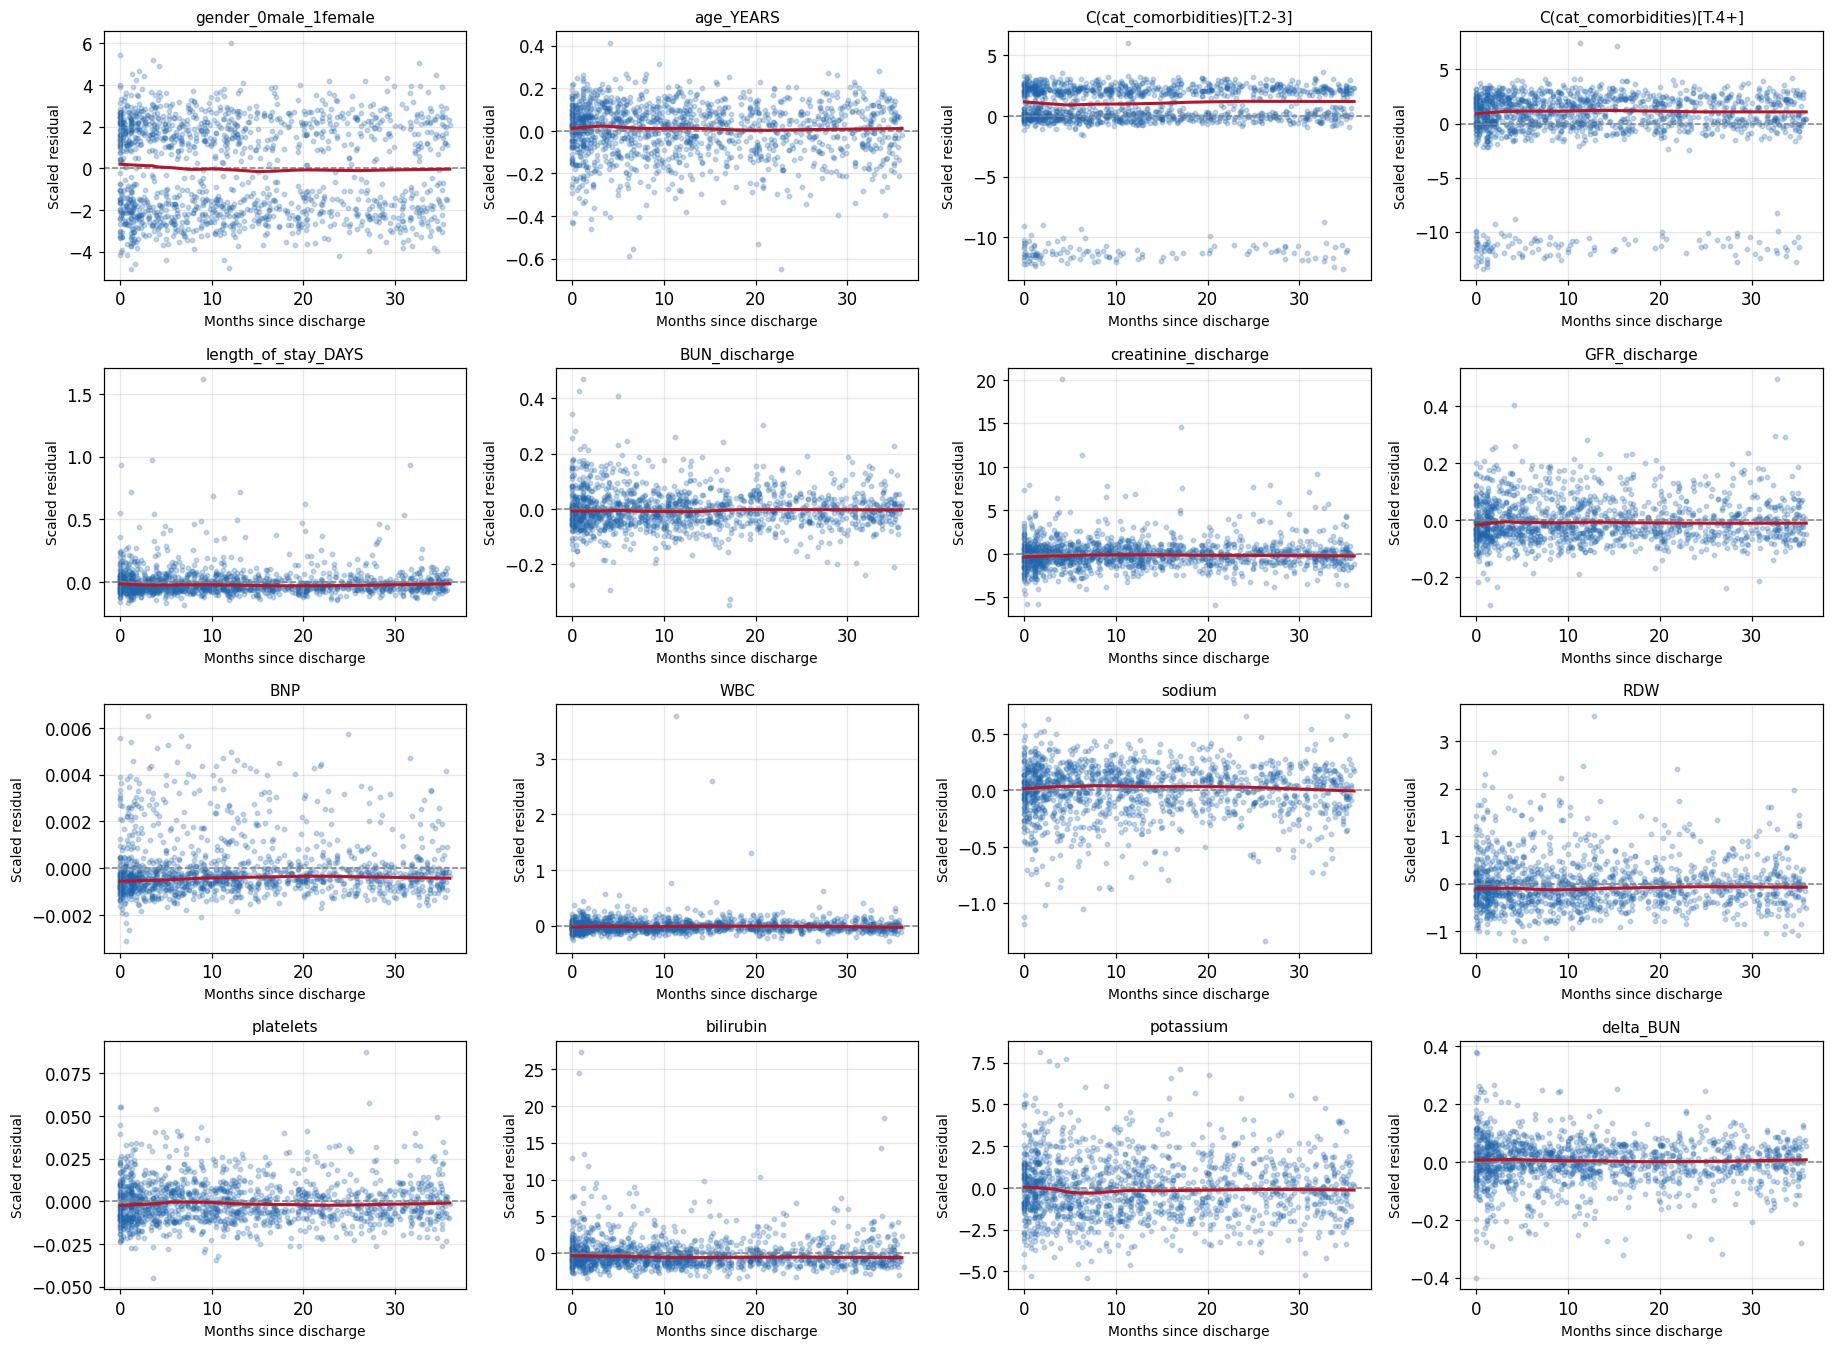

In [15]:
from statsmodels.nonparametric.smoothers_lowess import lowess

schoenfeld = cox_train.compute_residuals(train_df, kind="scaled_schoenfeld")
event_times = train_df.loc[schoenfeld.index, TIME_COL]

n_cols = 4
n_rows = int(np.ceil(len(schoenfeld.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.1 * n_rows))
axes = axes.flatten()

for ax, covariate in zip(axes, schoenfeld.columns):
    x = event_times.values
    y = schoenfeld[covariate].values
    order = np.argsort(x)
    x, y = x[order], y[order]

    ax.scatter(x, y, alpha=0.25, s=8, color="#2166ac")
    ax.axhline(0, linestyle="--", linewidth=1, color="grey")
    smoothed = lowess(y, x, frac=0.4, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], linewidth=2, color="#b2182b")
    ax.set_title(covariate, fontsize=10)
    ax.set_xlabel("Months since discharge", fontsize=9)
    ax.set_ylabel("Scaled residual", fontsize=9)

for j in range(len(schoenfeld.columns), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig5_schoenfeld_train.png"))
plt.show()

Figure 5. Scaled Schoenfeld residuals against time since discharge for all sixteen terms in the refitted model, each with a lowess smoother.

The smoothers are close to flat almost everywhere. Nothing shows the steady rise or fall that a genuinely time-varying hazard ratio would produce. The three terms the test flagged in Table 6 look no different by eye from the thirteen it did not, which supports reading those flags as noise rather than structure.

The two comorbidity burden panels look unlike the rest because the variable enters as dummy indicators, so the residuals fall into bands rather than a cloud. That is a feature of how the variable is coded, not evidence of a violation.

Taken together with Table 6, the graphical and formal evidence agree: the proportional hazards assumption holds well enough for this model on the training data.

---
# 6. One-year survival prediction using the refitted Cox model

For a patient with covariates X, the Cox model gives the one-year survival probability as the baseline survival at twelve months raised to the power of the relative risk:

$\hat S(\text{1 year}| X) = \hat S_0(\text{1 year})^{e^{X^T \hat \beta}}$

where $\hat S_0$ comes from the Breslow estimator on the training data and $\hat \beta$ are the coefficients in Table 5.

Each plot below varies one covariate and holds the other fourteen at representative values taken from the training set: the median for continuous covariates and the most common level for comorbidity burden, which is 2-3. The representative patient is printed with the figure.

The grids run from the 1st to the 99th percentile of each covariate in the training data rather than from the minimum to the maximum. Discharge BUN reaches 199.7 mg/dL in the training set but its upper quartile is 38, so the full range would spend most of the axis in a region holding almost no patients. The same grids and the same representative values are reused in Section 8, where the other three models are drawn on these axes.

Baseline S0(12 months)              = 0.7896
Representative patient S(12 months) = 0.8207


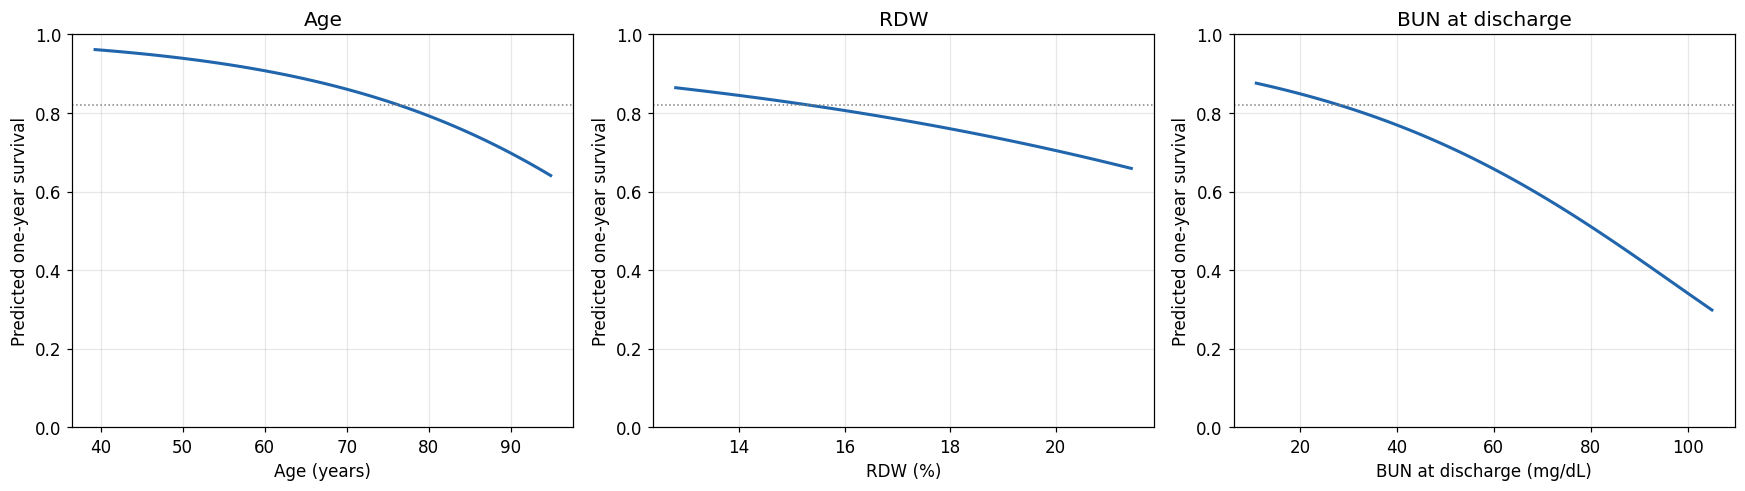


                     representative value
gender_0male_1female                  0.0
age_YEARS                        76.27293
cat_comorbidities                     2-3
length_of_stay_DAYS              5.106984
BUN_discharge                        28.0
creatinine_discharge                 1.23
GFR_discharge                   50.433085
BNP                                 778.1
WBC                                  8.92
sodium                              138.0
RDW                                  15.3
platelets                           225.0
bilirubin                             0.6
potassium                             4.3
delta_BUN                            2.59



,grid low,grid high,S at grid low,S at grid high,drop over grid,Q1,Q3,S at Q1,S at Q3,drop over IQR
covariate,,,,,,,,,,
Age (years),39.323,94.831,0.962,0.641,0.321,67.094,83.143,0.876,0.766,0.110
RDW (%),12.800,21.433,0.864,0.659,0.205,14.500,16.200,0.836,0.802,0.034
BUN at discharge (mg/dL),11.000,105.000,0.876,0.298,0.577,22.000,38.000,0.842,0.779,0.064


In [16]:
PLOT_COVARIATES = {
    "age_YEARS": "Age (years)",
    "RDW": "RDW (%)",
    "BUN_discharge": "BUN at discharge (mg/dL)",
}

base_train = representative_row(train_df, MODEL_VARS)
plot_grids = {}
for covariate in PLOT_COVARIATES:
    low, high = train_df[covariate].quantile([0.01, 0.99])
    plot_grids[covariate] = np.linspace(low, high, 120)

baseline = cox_train.baseline_survival_
s0_year = baseline[baseline.index <= HORIZON].iloc[-1, 0]
s_rep = float(cox_train.predict_survival_function(base_train, times=[HORIZON]).iloc[0, 0])
print(f"Baseline S0(12 months)              = {s0_year:.4f}")
print(f"Representative patient S(12 months) = {s_rep:.4f}")

summary_rows = []
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
for ax, (covariate, label) in zip(axes, PLOT_COVARIATES.items()):
    grid = plot_grids[covariate]
    curve = one_year_curve(cox_train, covariate, grid, base_train)
    ax.plot(grid, curve, color="#2166ac", linewidth=2)
    ax.axhline(s_rep, color="grey", linestyle=":", linewidth=1)
    ax.set_xlabel(label)
    ax.set_ylabel("Predicted one-year survival")
    ax.set_title(label.split(" (")[0])
    ax.set_ylim(0, 1)

    q1, q3 = train_df[covariate].quantile([0.25, 0.75])
    s_q1, s_q3 = one_year_curve(cox_train, covariate, np.array([q1, q3]), base_train)
    summary_rows.append([label, grid[0], grid[-1], curve[0], curve[-1], curve[0] - curve[-1],
                         q1, q3, s_q1, s_q3, s_q1 - s_q3])

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig6_cox_one_year.png"))
plt.show()

prediction_ranges = pd.DataFrame(summary_rows, columns=[
    "covariate", "grid low", "grid high", "S at grid low", "S at grid high", "drop over grid",
    "Q1", "Q3", "S at Q1", "S at Q3", "drop over IQR"]).set_index("covariate").round(3)
prediction_ranges.to_csv(os.path.join(TAB_DIR, "table7_cox_prediction_ranges.csv"))

print()
print(base_train.T.rename(columns={0: "representative value"}).to_string())
print()
prediction_ranges

Figure 6. The representative patient is a man of 76 with two or three comorbidities, discharge BUN of 28 mg/dL and RDW of 15.3, and his predicted one-year survival is 0.821. That is the dotted line in each panel, and each curve passes through it at the covariate's median. The baseline S0(12 months) is 0.790, which corresponds to a patient with every covariate at zero and so does not describe anyone in the cohort.

Across the plotted range, discharge BUN moves the prediction furthest: from 0.876 at 11 mg/dL down to 0.298 at 105. Age comes next, 0.962 at 39 years down to 0.641 at 95. RDW moves least, 0.864 down to 0.659.

Comparing the covariates over their interquartile ranges instead reverses the order. Between the first and third quartiles age moves predicted survival from 0.876 to 0.766, a drop of 0.11; discharge BUN from 0.842 to 0.779, a drop of 0.06; and RDW from 0.836 to 0.802, a drop of 0.03. For a patient in the middle of the distribution age therefore separates predictions most. Discharge BUN dominates the plotted range because of its long right tail, so it matters most for the minority of patients who leave with high values.

All three curves decline monotonically and flatten as survival falls, which is a property of the model rather than a finding: with a linear predictor, S0 raised to exp(X'b) can only be monotone in each covariate, and the flattening follows from raising a number below one to a growing power.

---
# 7. Fitting additional survival prediction models

Three models are added: a random survival forest, DeepSurv and Cox-Time. All three use the same covariates as the refitted Cox model of Section 5, so anything that separates them comes from the model and not from the information it was given. Each gives up a different part of the Cox model, which is what RQ2 asks about: DeepSurv keeps proportional hazards and drops linearity and additivity, Cox-Time drops proportional hazards as well, and the forest assumes none of the three.

Every model is tuned on the training data and refit on all 3,168 training patients. The test set is not touched until Section 9.

## 7.1 Validation procedure

The Cox model was fitted from a formula, so lifelines built its own design matrix. The other three models need it explicitly: the fourteen continuous covariates and the two comorbidity burden dummies with 0-1 as the reference level, which are the sixteen terms of Table 5. `cat_comorbidities` is a categorical variable, so `get_dummies` returns the same columns for any subset of the data, including the test set.

Hyperparameters are chosen by 5-fold cross-validation inside the training set. The folds are drawn once with the seed of Section 4 and reused for all three models. Each configuration is fitted on four folds and scored on the fifth by the integrated Brier score over months 1 to 12, the measure Section 9 reports. Cross-validation is used rather than one held-out block because about a fifth of the cohort dies within the first year, so a single validation split would be scored on a few hundred events and would mostly rank noise.

Mean IBS alone is not enough to pick a configuration: with five folds the scores for nearby configurations are close enough that the outright minimum is often noise. The configuration used is instead chosen by a one-standard-error rule — among the configurations within one SE of the lowest mean IBS, the simplest is kept: largest leaves and fewest features per split for the forest, fewest and smallest hidden units and highest dropout for the two networks. The selected configuration is then refit on all 3,168 training patients. The refitted Cox model of Section 5 is scored on the same five folds as a reference row, so Section 7.5 can compare the added flexibility of the other three models against a fair Cox baseline rather than against the full-data fit.

The number of epochs is not part of any grid. Inside each fold a further 20% of the fitting data is held out to stop training; `EarlyStopping` keeps training for ten epochs past the best validation loss and restores the best weights, so what is recorded is the epoch of that best loss, not the number of epochs run. The final networks are then trained on all 3,168 patients for the average of those epoch counts across folds. A fold fits on 2,027 patients against 3,168 for the final model, so an epoch there is fewer gradient updates than an epoch at the final fit, and the transferred count is an approximation. All four models therefore end up fitted on the same data.

Section 7.6 saves all four fitted models to `trained_models/` so that Sections 8 and 9 can load them without repeating the search.

In [17]:
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sksurv.util import Surv
from sksurv.metrics import integrated_brier_score

CAT_COL = "cat_comorbidities"
NUMERIC_VARS = [c for c in MODEL_VARS if c != CAT_COL]
EVAL_TIMES = np.arange(1.0, HORIZON + 1.0)      # months 1 to 12
FOLDS = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(train_df))


def design_matrix(data):
    # the sixteen terms of Table 5: fourteen continuous covariates and two comorbidity dummies
    dummies = pd.get_dummies(data[CAT_COL], prefix="comorb", drop_first=True)
    return pd.concat([data[NUMERIC_VARS], dummies], axis=1).astype("float32")


def surv_target(data):
    return Surv.from_arrays(event=data[EVENT_COL].astype(bool), time=data[TIME_COL])


def target_tuple(data):
    return (data[TIME_COL].values.astype("float32"), data[EVENT_COL].values.astype("float32"))


def surv_at_times(curves, times):
    """Step-function lookup on curves whose index is time: one row per patient, one column per time."""
    return curves.reindex(curves.index.union(times)).ffill().fillna(1.0).loc[times].T.to_numpy()


def one_year_ibs(curves, d_fit, d_val):
    # IPCW weights come from the fitting folds, the predictions from the held-out fold
    return integrated_brier_score(surv_target(d_fit), surv_target(d_val),
                                  surv_at_times(curves, EVAL_TIMES), EVAL_TIMES)


def cv_search(fit_fold, grid):
    """Mean and SE of the cross-validated IBS for every configuration in `grid`, best first."""
    rows = []
    for params in grid:
        scores, epochs = [], []
        for fit_idx, val_idx in FOLDS:
            d_fit, d_val = train_df.iloc[fit_idx], train_df.iloc[val_idx]
            curves, n_epochs = fit_fold(params, d_fit, d_val)
            scores.append(one_year_ibs(curves, d_fit, d_val))
            epochs.append(n_epochs)
        rows.append({**params, "IBS": np.mean(scores),
                     "IBS_SE": np.std(scores, ddof=1) / np.sqrt(len(scores)),
                     "epochs": np.mean(epochs)})
    return pd.DataFrame(rows).sort_values("IBS").reset_index(drop=True)


def best_of(results, complexity=None):
    """The winning configuration and its row.

    With no `complexity`, the outright best (lowest mean IBS). With `complexity` (a function
    mapping a results row to a sortable "simplicity" key, smallest = simplest), the simplest
    configuration among those within one SE of the best -- a one-standard-error rule.
    """
    candidates = results
    if complexity is not None:
        threshold = results["IBS"].iloc[0] + results["IBS_SE"].iloc[0]
        candidates = results[results["IBS"] <= threshold].copy()
        candidates["_complexity"] = candidates.apply(complexity, axis=1)
        candidates = candidates.sort_values("_complexity")
    row = candidates.iloc[0]
    drop_cols = [c for c in ["IBS", "IBS_SE", "epochs", "_complexity"] if c in row.index]
    params = row.drop(drop_cols)
    # pandas widens a row to float; put the integer-valued settings back
    params = {k: int(v) if isinstance(v, float) and v.is_integer() else v for k, v in params.items()}
    return params, row


def fit_cox_fold(params, d_fit, d_val):
    # a reference row: the refitted Cox model of Section 5, scored on the same five folds
    model = CoxPHFitter().fit(d_fit, duration_col=TIME_COL, event_col=EVENT_COL, formula=PA2_FORMULA)
    return model.predict_survival_function(d_val), np.nan


X_train = design_matrix(train_df)
y_train = surv_target(train_df)
print(f"Design columns ({X_train.shape[1]}): {', '.join(X_train.columns)}")
print(f"{len(FOLDS)}-fold cross-validation on {len(train_df)} training patients, "
      f"scored by IBS over months {EVAL_TIMES[0]:.0f} to {EVAL_TIMES[-1]:.0f}")

cox_results = cv_search(fit_cox_fold, [{}])
print(f"Cox (reference row, same folds): CV IBS = {cox_results.iloc[0]['IBS']:.4f} "
      f"+/- {cox_results.iloc[0]['IBS_SE']:.4f}")

Design columns (16): gender_0male_1female, age_YEARS, length_of_stay_DAYS, BUN_discharge, creatinine_discharge, GFR_discharge, BNP, WBC, sodium, RDW, platelets, bilirubin, potassium, delta_BUN, comorb_2-3, comorb_4+
5-fold cross-validation on 3168 training patients, scored by IBS over months 1 to 12
Cox (reference row, same folds): CV IBS = 0.1175 +/- 0.0033


## 7.2 Random survival forest

The forest grows 500 trees on bootstrap samples of the training data. At each node it splits on the covariate and cut point maximising the log-rank statistic between the two children, so nodes separate patients who die early from those who do not. Each terminal node carries the Nelson-Aalen cumulative hazard of the training patients that fell into it, and a patient's survival curve is the average, over the 500 trees, of the curve in the node they reach.

Two hyperparameters are tuned:

* `min_samples_leaf` over 5, 15, 30, 50. This sets how many patients stand behind each terminal Nelson-Aalen estimate and is the main bias-variance knob. At a 42% event rate a leaf of 5 holds about two deaths and gives a very noisy curve, while a leaf of 50 holds about 21 and gives a smooth but coarse one.
* `max_features` over 4, 8, 16, that is from the usual square root of the number of columns up to all of them. With only sixteen columns, of which age, discharge BUN and RDW carry most of the signal, sampling four per split often leaves the strong covariates unavailable. That restriction is what decorrelates the trees, but it may be too aggressive at this width, so it is settled empirically.

The rest is fixed: 500 trees, because more trees only reduce the variance of the average and cannot overfit, so this is a compute choice and not a bias-variance one; `min_samples_split` at twice the leaf size and `max_depth` unbounded, both redundant with the leaf size once it is tuned.

Averaging 500 trees removes most of a single leaf's noise, which is why a small leaf can still score well in cross-validation even though any one tree's terminal curve is noisy. The one-standard-error rule of 7.1 corrects for this by pulling the final choice toward the simpler, larger-leaf end of the grid whenever a simpler configuration scores within noise of the best one.

In [18]:
from sksurv.ensemble import RandomSurvivalForest

RSF_TREES = 500
RSF_GRID = list(ParameterGrid({"min_samples_leaf": [5, 15, 30, 50], "max_features": [4, 8, 16]}))


def rsf_complexity(row):
    # simpler = larger leaves first, fewer features per split as a tie-break
    return (-row["min_samples_leaf"], row["max_features"])


def make_rsf(params):
    leaf = int(params["min_samples_leaf"])
    return RandomSurvivalForest(n_estimators=RSF_TREES, random_state=SEED, n_jobs=-1,
                                min_samples_leaf=leaf, min_samples_split=2 * leaf,
                                max_features=int(params["max_features"]))


def rsf_surv(model, data):
    curves = model.predict_survival_function(design_matrix(data), return_array=True)
    return pd.DataFrame(curves.T, index=model.unique_times_)


def fit_rsf_fold(params, d_fit, d_val):
    model = make_rsf(params).fit(design_matrix(d_fit), surv_target(d_fit))
    return rsf_surv(model, d_val), np.nan


rsf_results = cv_search(fit_rsf_fold, RSF_GRID)
rsf_params, rsf_row = best_of(rsf_results, complexity=rsf_complexity)
rsf = make_rsf(rsf_params).fit(X_train, y_train)

print("Selected:", ", ".join(f"{k} = {v}" for k, v in rsf_params.items()),
      f"   CV IBS: {rsf_row['IBS']:.4f} +/- {rsf_row['IBS_SE']:.4f}")

Selected: max_features = 4, min_samples_leaf = 50    CV IBS: 0.1196 +/- 0.0035


## 7.3 DeepSurv

DeepSurv keeps the Cox partial likelihood and replaces the linear predictor with a neural network, so a patient's log relative risk is $g(X)$ rather than $X^T \beta$ and survival is read exactly as in Section 6,

$\hat S(t | X) = \hat S_0(t)^{e^{g(X)}}$,

with $\hat S_0$ the Breslow estimator on the training data. Hazards stay proportional, since $e^{g(x_1) - g(x_2)}$ does not involve $t$. What the network adds is a risk score free to bend with each covariate and to let covariates modify one another.

Three hyperparameters are tuned:

* hidden layers over [16], [32, 32] and [64, 64]. This decides how much non-linearity the model can express and is the main overfitting risk with sixteen inputs and 3,168 patients. A single layer of 16 is close to the Cox model and serves as a floor: if it wins, the flexibility is not being used.
* dropout over 0.1 and 0.4, the main regulariser, so that the larger networks are not judged on overfitting alone.
* learning rate over 0.01 and 0.001. At batch size 256 an epoch is about ten updates, so Adam at 0.01 takes few large steps, which together with batch normalisation can be unstable.

Fixed: Adam, batch size 256, at most 512 epochs, early stopping after 10 epochs without improvement in the held-out loss with the weights restored to the best epoch, and no output bias, since a constant in $g$ would be absorbed into the baseline hazard. The covariates are standardised because gradient descent needs them on a common scale, with the scaler fitted on the data the network trains on.

In [19]:
import warnings
import torch
import torchtuples as tt
from pycox.models import CoxPH, CoxTime
from pycox.models.cox_time import MLPVanillaCoxTime

# torchtuples indexes with a list rather than a tuple in a few internal spots; harmless with the
# pinned torch version here but noisy across ~120 fold fits, so it is silenced rather than printed
warnings.filterwarnings("ignore", category=UserWarning, module="torchtuples")

BATCH_SIZE = 256
MAX_EPOCHS = 512
PATIENCE = 10
NET_GRID = list(ParameterGrid({"hidden": [[16], [32, 32], [64, 64]],
                               "dropout": [0.1, 0.4], "lr": [0.01, 0.001]}))


def net_complexity(row):
    # simpler = fewer/smaller hidden units first, higher dropout as a tie-break
    return (sum(row["hidden"]), -row["dropout"])


def train_net(params, data, cox_time, epochs=None, stop_data=None):
    """Fit one network on `data`, stopping on `stop_data` if given, else running `epochs` epochs.

    Returns the epoch of the best validation loss when early stopping is used -- `EarlyStopping`
    keeps training for `PATIENCE` epochs past that point and restores the best weights, so the
    number of epochs run is not the number that should be transferred to the final fit.
    """
    scaler = StandardScaler().fit(design_matrix(data))
    x, y = scaler.transform(design_matrix(data)).astype("float32"), target_tuple(data)
    labtrans = CoxTime.label_transform() if cox_time else None
    if cox_time:
        y = labtrans.fit_transform(*y)

    torch.manual_seed(SEED)
    if cox_time:
        net = MLPVanillaCoxTime(x.shape[1], params["hidden"], batch_norm=True, dropout=params["dropout"])
        model = CoxTime(net, tt.optim.Adam(params["lr"]), labtrans=labtrans)
    else:
        net = tt.practical.MLPVanilla(x.shape[1], params["hidden"], out_features=1, batch_norm=True,
                                      dropout=params["dropout"], output_bias=False)
        model = CoxPH(net, tt.optim.Adam(params["lr"]))

    callbacks, val_data = [], None
    if stop_data is not None:
        y_stop = target_tuple(stop_data)
        val_data = tt.tuplefy(scaler.transform(design_matrix(stop_data)).astype("float32"),
                              labtrans.transform(*y_stop) if cox_time else y_stop)
        if cox_time:
            val_data = val_data.repeat(10).cat()   # the case-control loss is sampled
        callbacks, epochs = [tt.callbacks.EarlyStopping(patience=PATIENCE)], MAX_EPOCHS

    log = model.fit(x, y, batch_size=BATCH_SIZE, epochs=epochs, callbacks=callbacks,
                    val_data=val_data, verbose=False)
    model.compute_baseline_hazards()

    log_df = log.to_pandas()
    n_epochs = len(log_df)
    if stop_data is not None:
        val_col = "val_loss" if "val_loss" in log_df.columns else log_df.columns[-1]
        n_epochs = int(log_df[val_col].idxmin()) + 1   # epoch of the best (restored) weights
    return model, scaler, n_epochs


def net_surv(model, scaler, data):
    return model.predict_surv_df(scaler.transform(design_matrix(data)).astype("float32"))


def fit_net_fold(params, d_fit, d_val, cox_time):
    d_fit, d_stop = train_test_split(d_fit, test_size=0.2, random_state=SEED,
                                     stratify=d_fit[EVENT_COL])
    model, scaler, epochs = train_net(params, d_fit, cox_time, stop_data=d_stop)
    return net_surv(model, scaler, d_val), epochs


ds_results = cv_search(lambda p, a, b: fit_net_fold(p, a, b, cox_time=False), NET_GRID)
ds_params, ds_row = best_of(ds_results, complexity=net_complexity)
ds_epochs = int(round(ds_row["epochs"]))
deepsurv, deepsurv_scaler, _ = train_net(ds_params, train_df, cox_time=False, epochs=ds_epochs)

print("Selected:", ", ".join(f"{k} = {v}" for k, v in ds_params.items()),
      f"   CV IBS: {ds_row['IBS']:.4f} +/- {ds_row['IBS_SE']:.4f}   epochs: {ds_epochs}")

Selected: dropout = 0.4, hidden = [16], lr = 0.001    CV IBS: 0.1171 +/- 0.0030   epochs: 108


## 7.4 Cox-Time

Cox-Time drops proportional hazards. The risk score becomes $g(t, X)$, so time enters the network as a seventeenth input and the hazard ratio between two patients is free to change over follow-up. Survival is $\hat S(t | X) = e^{-\hat H(t | X)}$, where $\hat H$ accumulates the baseline hazard weighted by $e^{g(t, X)}$ over the observed event times up to $t$. Durations are standardised by the label transform on the way in and predicted curves are mapped back to months on the way out. The full partial likelihood would require evaluating the network at every event time for everyone still at risk, so training uses case-control sampling instead.

The grid, the fixed settings and the trainer are the same as DeepSurv, so that the difference between the two networks in Sections 8 and 9 is the proportional hazards assumption rather than unequal tuning. Two settings are specific to this model and are fixed: one control per event, which keeps the cost per epoch equal to DeepSurv's, and the data used for stopping repeated ten times, since a sampled loss on a single copy is too noisy to stop on.

In [20]:
ct_results = cv_search(lambda p, a, b: fit_net_fold(p, a, b, cox_time=True), NET_GRID)
ct_params, ct_row = best_of(ct_results, complexity=net_complexity)
ct_epochs = int(round(ct_row["epochs"]))
coxtime, coxtime_scaler, _ = train_net(ct_params, train_df, cox_time=True, epochs=ct_epochs)

print("Selected:", ", ".join(f"{k} = {v}" for k, v in ct_params.items()),
      f"   CV IBS: {ct_row['IBS']:.4f} +/- {ct_row['IBS_SE']:.4f}   epochs: {ct_epochs}")

Selected: dropout = 0.4, hidden = [16], lr = 0.01    CV IBS: 0.1192 +/- 0.0035   epochs: 24


## 7.5 Selected models and one-year predictions

Table 8 collects the selected configuration for each model together with its cross-validated IBS and standard error, plus a Cox row fit on the same five folds as a reference. That score chose the configuration -- for Cox it is shown only for comparison, since the model actually used below is the full refit of Section 5 -- and is not a performance estimate; Section 9 provides those on the test set.

The cell also defines `SURVIVAL_CURVES` and `one_year_survival`, which return the predicted survival curve and $\hat S(12)$ for any set of patients under any of the four models. Sections 8 and 9 call these and refit nothing; Section 7.6 saves the four fitted models so that this holds across kernel restarts as well.

In [21]:
selected = pd.DataFrame(
    [{"model": name,
      "selected hyperparameters": ", ".join(f"{k} = {v}" for k, v in params.items()),
      "CV IBS": row["IBS"], "CV IBS SE": row["IBS_SE"]}
     for name, params, row in [
         ("Cox (reference)", {}, cox_results.iloc[0]),
         ("RSF", {**rsf_params, "n_estimators": RSF_TREES}, rsf_row),
         ("DeepSurv", {**ds_params, "epochs": ds_epochs}, ds_row),
         ("Cox-Time", {**ct_params, "epochs": ct_epochs}, ct_row),
     ]]
).set_index("model").round(4)
selected.to_csv(os.path.join(TAB_DIR, "table8_selected_hyperparameters.csv"))

SURVIVAL_CURVES = {
    "Cox": lambda data: cox_train.predict_survival_function(data),
    "RSF": lambda data: rsf_surv(rsf, data),
    "DeepSurv": lambda data: net_surv(deepsurv, deepsurv_scaler, data),
    "Cox-Time": lambda data: net_surv(coxtime, coxtime_scaler, data),
}


def one_year_survival(model_name, data):
    curves = SURVIVAL_CURVES[model_name](data)
    return curves.loc[curves.index <= HORIZON].iloc[-1].values


print("Mean predicted one-year survival on the training set: " + "   ".join(
    f"{name} = {one_year_survival(name, train_df).mean():.3f}" for name in SURVIVAL_CURVES))
selected

Mean predicted one-year survival on the training set: Cox = 0.754   RSF = 0.755   DeepSurv = 0.750   Cox-Time = 0.752


,selected hyperparameters,CV IBS,CV IBS SE
model,,,
Cox (reference),,0.1175,0.0033
RSF,"max_features = 4, min_samples_leaf = 50, n_est...",0.1196,0.0035
DeepSurv,"dropout = 0.4, hidden = [16], lr = 0.001, epoc...",0.1171,0.0030
Cox-Time,"dropout = 0.4, hidden = [16], lr = 0.01, epoch...",0.1192,0.0035


## 7.6 Saving the fitted models

The four fitted models -- `cox_train`, `rsf`, `deepsurv` (with its scaler) and `coxtime` (with its scaler) -- are pickled to `trained_models/` so that Sections 8 and 9 can load them directly instead of repeating the cross-validated search.

In [22]:
import joblib

MODEL_DIR = "trained_models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(cox_train, os.path.join(MODEL_DIR, "cox_train.joblib"))
joblib.dump(rsf, os.path.join(MODEL_DIR, "rsf.joblib"))
joblib.dump({"model": deepsurv, "scaler": deepsurv_scaler}, os.path.join(MODEL_DIR, "deepsurv.joblib"))
joblib.dump({"model": coxtime, "scaler": coxtime_scaler}, os.path.join(MODEL_DIR, "coxtime.joblib"))

print(f"Saved fitted models to {MODEL_DIR}/: " + ", ".join(sorted(os.listdir(MODEL_DIR))))

Saved fitted models to trained_models/: cox_train.joblib, coxtime.joblib, deepsurv.joblib, rsf.joblib
